Project: Predicting Electricity Outage Recovery Time Using Deep Learning

Author: Luke McCarvill
* Supervisor: Dr. Yu Mo

Date: 9-April-2026

**Inspecting timeseries.pq file:**

In [2]:
import pandas as pd

# ts = pd.read_parquet("timeseries.pq") # 'ts' is the timeseries pandas dataframe
ts = pd.read_parquet(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq")

print(ts.shape)
print(ts.columns)
print(ts.dtypes)
print(ts.head())

(159522635, 2)
Index(['OutageFraction', 'CustomersTracked'], dtype='object')
OutageFraction      float64
CustomersTracked    float64
dtype: object
                           OutageFraction  CustomersTracked
RecordDateTime CountyFIPS                                  
2017-01-01     01001                  0.0               0.0
               01003                  0.0               0.0
               01005                  0.0               0.0
               01007                  0.0               0.0
               01009                  0.0               0.0


^ the above took 1min, 8sec to complete.
What learned:
* almost **160 million rows**
* only **2 columns: 'OutageFraction', 'CustomersTracked'**
* Index: RecordDateTime, CountyFIPS (This is a MultiIndex, not columns)
* actual outage count ≈ OutageFraction * CustomersTracked ?
    * though customersTracked varies and can be zero... not sure exact meaning


In [6]:
# inspect a slice:
ts.sample(5, random_state=0)

,,OutageFraction,CustomersTracked
RecordDateTime,CountyFIPS,,
2019-04-13 08:00:00,21077,0.000000,2364.0
2018-06-12 15:00:00,48285,0.000811,3700.0
2018-02-03 03:00:00,35007,0.000000,0.0
2018-02-09 22:00:00,48077,0.000000,0.0
2021-06-04 03:00:00,17103,0.000000,22615.0


Now, convert index to columns so it's easier to work with:

In [7]:
ts = ts.reset_index()

print(ts.head())
print(ts.dtypes)

  RecordDateTime CountyFIPS  OutageFraction  CustomersTracked
0     2017-01-01      01001             0.0               0.0
1     2017-01-01      01003             0.0               0.0
2     2017-01-01      01005             0.0               0.0
3     2017-01-01      01007             0.0               0.0
4     2017-01-01      01009             0.0               0.0
RecordDateTime      datetime64[ns]
CountyFIPS                  object
OutageFraction             float64
CustomersTracked           float64
dtype: object


^ makes sense; datatypes are datetime, object (to avoid losing leading zeros in the IDs), and floats

In [10]:
# explicitly define recorddatetime as datetime and countyFIPS as string (object)
    # this was already the case I think but at least it's safe
ts["RecordDateTime"] = pd.to_datetime(ts["RecordDateTime"])
ts["CountyFIPS"] = ts["CountyFIPS"].astype(str).str.zfill(5)

# check min and max time
print(ts["RecordDateTime"].min(), ts["RecordDateTime"].max())
# check number of unique FIPS codes
print(ts["CountyFIPS"].nunique())

2017-01-01 00:00:00 2022-12-31 00:00:00
3035


^ interpretation:
* data goes from **1-Jan-2017** to **31-Dec-2022**
* **3035 total unique FIPS codes** included in the dataset. 
    * apparently there are ~3252 counties (and county equivalents) in the USA, so this seems sensible

Now, filter to just florida (FIPS codes starting with 12)

In [12]:
ts_fl = ts[ts["CountyFIPS"].str.startswith("12")]
# and then check size of this smaller dataframe
print(ts_fl.shape)

(3521587, 4)


^ that reduced the number of rows to 3.5 million (from 160 million)
* and there are now 4 columns since the indices are now columns

**Now, load POUS.csv data**

In [14]:
pous = pd.read_csv(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv")

# quick check so I know it loaded properly
print(pous.shape)
print(pous.columns)
print(pous.head())

(1040, 13)
Index(['event_start', 'CountyFIPS', 'county_pop',
       'pre_outage_tracked_customers', 'days_since_data_start',
       'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost',
       'storm', 'duration_days', 'year', 'month'],
      dtype='object')
           event_start  CountyFIPS  county_pop  pre_outage_tracked_customers  \
0  2017-06-21 16:00:00       54001       15414                        6599.0   
1  2017-06-24 04:00:00       54059       22573                       13970.0   
2  2017-07-30 21:00:00       12075       45260                        2942.7   
3  2017-08-24 22:00:00       21055        8981                        3092.0   
4  2017-08-25 21:00:00       48355      351674                      143346.0   

   days_since_data_start  duration_hours  n_periods   integral  \
0             171.625000              47         47   0.389301   
1             174.125000              62         62   4.778789   
2             210.833333              86        

^ 1040 rows, 13 columns
* includes column CountyFIPS

Check Florida event table:

In [15]:
pous["event_start"] = pd.to_datetime(pous["event_start"], errors="coerce")
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)

# Florida counties start with 12
florida_events = pous[pous["CountyFIPS"].str.startswith("12")].copy()

# Basic sanity checks
print("Florida event rows:", len(florida_events))
print("Unique Florida counties:", florida_events["CountyFIPS"].nunique())
print("Unique Florida storms:", florida_events["storm"].nunique())

Florida event rows: 99
Unique Florida counties: 64
Unique Florida storms: 10


^ 99 events across 10 storms from 2017-2022, so ~10 counties per storm

In [20]:
# Check that event_start really is datetime
print("event_start dtype:", florida_events["event_start"].dtype)
print("Any missing event_start values:", florida_events["event_start"].isna().sum())

# Quick peek so we can see if the rows look sensible
display(
    florida_events[
        ["event_start", "CountyFIPS", "county_pop", "duration_hours", "storm", "year", "month"]
    ].head(10)
)

event_start dtype: datetime64[ns]
Any missing event_start values: 0


,event_start,CountyFIPS,county_pop,duration_hours,storm,year,month
2,2017-07-30 21:00:00,12075,45260,86,2017212N28275,2017,7
35,2017-09-09 19:00:00,12037,12498,122,2017242N16333,2017,9
37,2017-09-09 20:00:00,12059,19651,43,2017242N16333,2017,9
38,2017-09-09 20:00:00,12067,7786,191,2017242N16333,2017,9
39,2017-09-09 21:00:00,12013,13464,54,2017242N16333,2017,9
40,2017-09-09 22:00:00,12075,45260,190,2017242N16333,2017,9
44,2017-09-10 02:00:00,12079,18198,124,2017242N16333,2017,9
45,2017-09-10 06:00:00,12011,1947026,178,2017242N16333,2017,9
46,2017-09-10 06:00:00,12086,2673837,210,2017242N16333,2017,9
47,2017-09-10 11:00:00,12125,15460,133,2017242N16333,2017,9


^ cluster in Sept 2017 likely Hurricane Irma

In [21]:
# pick one event (just take the first for now)
event = florida_events.iloc[0]

# extract key info
event_start = event["event_start"]
county_fips = event["CountyFIPS"]

# define a 5-day window (zoom-in)
event_end = event_start + pd.Timedelta(days=5)

print("Selected event:")
print(event)

print("\nWindow:")
print("Start:", event_start)
print("End:", event_end)
# ^ note this is arbitrarily assuming the 'event' ends 5 days after it started; this is not the true duration of the storm

Selected event:
event_start                     2017-07-30 21:00:00
CountyFIPS                                    12075
county_pop                                    45260
pre_outage_tracked_customers                 2942.7
days_since_data_start                    210.833333
duration_hours                                   86
n_periods                                        86
integral                                    4.00755
pop_hours_supply_lost                 181381.722464
storm                                 2017212N28275
duration_days                              3.583333
year                                           2017
month                                             7
Name: 2, dtype: object

Window:
Start: 2017-07-30 21:00:00
End: 2017-08-04 21:00:00


^ storm *2017212N28275* was Tropical Storm EMILY
* source: https://ncics.org/ibtracs/index.php?name=v04r01-2017212N28275
    * Start	Jul 30 18Z
        * ^ i believe that's 18:00 ISO time
    * Landfall	Jul 31 18Z
    * End	Aug 2 00Z
* per 'POUS.csv', it started July 30th at 21:00 and lasted for 3.58 days.

Perhaps let's instead look at Hurricane Irma:

In [ ]:
# pick an event (second one (index=1), to skip the Emily instance)
event = florida_events.iloc[1] # this results in it choosing storm Irma on county 12037 (Franklin County).

# extract key info
event_start = event["event_start"]
county_fips = event["CountyFIPS"]

# define a 6-day window (zoom-in)
event_end = event_start + pd.Timedelta(days=6)

print("Selected event:")
print(event)

print("\nWindow:")
print("Start:", event_start)
print("End:", event_end)
# ^ note this is arbitrarily assuming the 'event' ends 5 or 6 days after it started; this is not the true duration of the storm

Selected event:
event_start                     2017-09-09 19:00:00
CountyFIPS                                    12037
county_pop                                    12498
pre_outage_tracked_customers                 9491.0
days_since_data_start                        251.75
duration_hours                                  122
n_periods                                       122
integral                                  13.391149
pop_hours_supply_lost                 167362.578134
storm                                 2017242N16333
duration_days                              5.083333
year                                           2017
month                                             9
Name: 35, dtype: object

Window:
Start: 2017-09-09 19:00:00
End: 2017-09-15 19:00:00


^ storm *2017242N16333* was Major Hurricane IRMA
* source: https://ncics.org/ibtracs/index.php?name=v04r01-2017242N16333
    * Start	Aug 30 00Z
    * Landfall	Sep 10 19Z
    * Max Intensity	155 kt (Sep 5 18Z), 914 mb (Sep 6 03Z)
    * End	Sep 13 12Z
* per 'POUS.csv', it started Sept 9th at 19:00 and lasted for 5.08 days.
    * so, I updated the window length to be 6 days instead of 5

Now, let's extract the matching timeseries data from the ***ts*** dataframe

In [38]:
one_event_ts = ts_fl[
    (ts_fl["CountyFIPS"] == county_fips) &
    (ts_fl["RecordDateTime"] >= event_start) &
    (ts_fl["RecordDateTime"] <= event_end)
].copy()

print(one_event_ts.shape)
display(one_event_ts.head())

(145, 4)


,RecordDateTime,CountyFIPS,OutageFraction,CustomersTracked
18340812,2017-09-09 19:00:00,12037,0.0,9491.0
18343847,2017-09-09 20:00:00,12037,0.0,9491.0
18346882,2017-09-09 21:00:00,12037,0.0,9491.0
18349917,2017-09-09 22:00:00,12037,0.0,9491.0
18352952,2017-09-09 23:00:00,12037,0.0,9491.0


^ 145 'events' (rows) with 4 columns

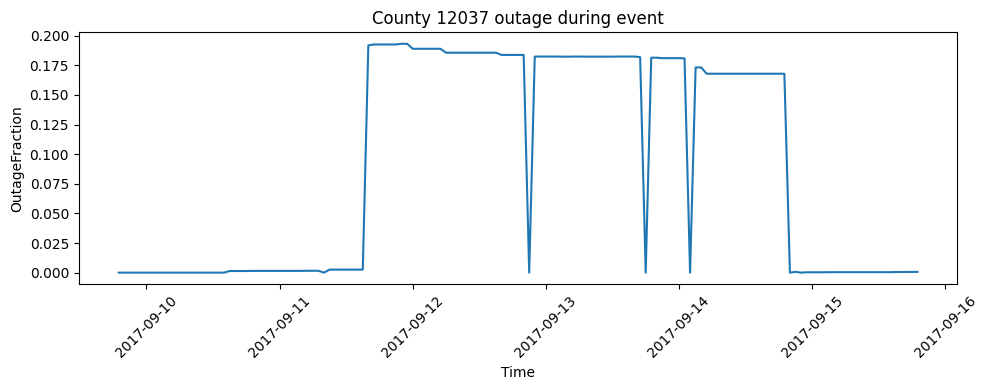

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(one_event_ts["RecordDateTime"], one_event_ts["OutageFraction"])
plt.title(f"County {county_fips} outage during event")
plt.xlabel("Time")
plt.ylabel("OutageFraction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

^ overall this is pretty good, but the drops to zero in the middle are likely from CustomersTracked going to zero and thus are data gaps / reporting dropouts, not real recovery

In [30]:
check = one_event_ts[
    (one_event_ts["OutageFraction"] == 0)
]

display(check[["RecordDateTime", "OutageFraction", "CustomersTracked"]])

,RecordDateTime,OutageFraction,CustomersTracked
18340812,2017-09-09 19:00:00,0.0,9491.0
18343847,2017-09-09 20:00:00,0.0,9491.0
18346882,2017-09-09 21:00:00,0.0,9491.0
18349917,2017-09-09 22:00:00,0.0,9491.0
18352952,2017-09-09 23:00:00,0.0,9491.0
18355987,2017-09-10 00:00:00,0.0,9491.0
18359022,2017-09-10 01:00:00,0.0,9491.0
18362057,2017-09-10 02:00:00,0.0,9491.0
18365092,2017-09-10 03:00:00,0.0,9491.0
18368127,2017-09-10 04:00:00,0.0,9491.0


^ this shows that CustomersTracked sometimes goes to zero, which seems to be missing data. not sure why this happens

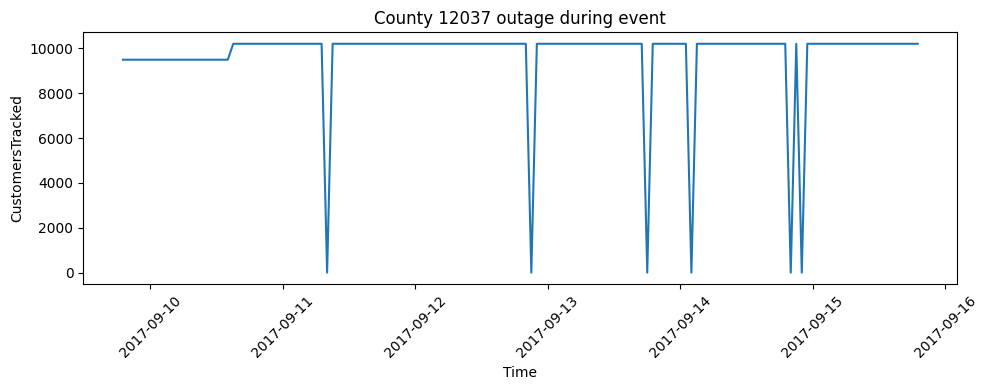

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(one_event_ts["RecordDateTime"], one_event_ts["CustomersTracked"])
plt.title(f"County {county_fips} outage during event")
plt.xlabel("Time")
plt.ylabel("CustomersTracked")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Later, we will need to handle missing data more explicitly, but for now, let's just break the line at these missing points

In [43]:
one_event_ts.loc[one_event_ts["CustomersTracked"] == 0, "OutageFraction"] = None
# for this subset dataset, find all the locations where customerstracked==0 and remove the data

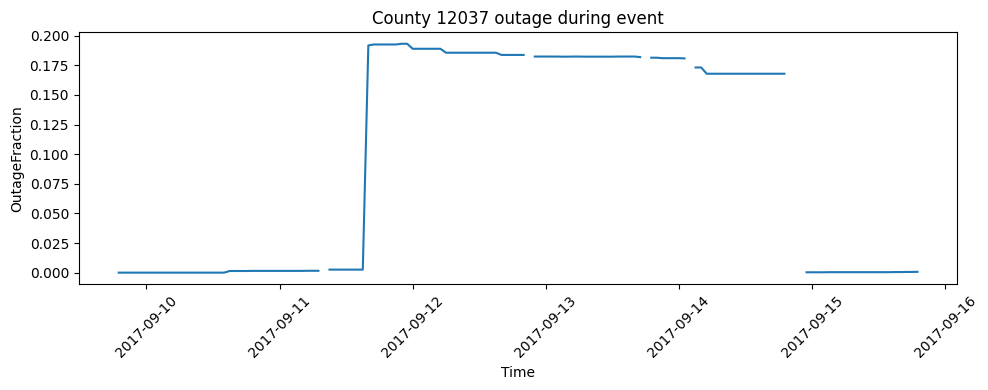

In [45]:
# now plot outage fraction with the zeros in customersTracked removed
plt.figure(figsize=(10, 4))
plt.plot(one_event_ts["RecordDateTime"], one_event_ts["OutageFraction"])
plt.title(f"County {county_fips} outage during event")
plt.xlabel("Time")
plt.ylabel("OutageFraction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let's try this with another event to see if this is a common issue

In [51]:
# pick another event
event2 = florida_events.iloc[20] # this results in it choosing Irma in Highlands County (12055)

# extract key info
event2_start = event2["event_start"]
county2_fips = event2["CountyFIPS"]

# define a 6-day window (zoom-in)
event2_end = event2_start + pd.Timedelta(days=10)

print("Selected event:")
print(event2)

print("\nWindow:")
print("Start:", event2_start)
print("End:", event2_end)
# ^ note this is arbitrarily assuming the 'event' ends X days after it started; this is not the true duration of the storm

Selected event:
event_start                     2017-09-10 22:00:00
CountyFIPS                                    12055
county_pop                                   105618
pre_outage_tracked_customers                54806.0
days_since_data_start                       252.875
duration_hours                                  219
n_periods                                       219
integral                                 142.440174
pop_hours_supply_lost               15044246.291017
storm                                 2017242N16333
duration_days                                 9.125
year                                           2017
month                                             9
Name: 66, dtype: object

Window:
Start: 2017-09-10 22:00:00
End: 2017-09-20 22:00:00


In [52]:
one_event2_ts = ts_fl[
    (ts_fl["CountyFIPS"] == county2_fips) &
    (ts_fl["RecordDateTime"] >= event2_start) &
    (ts_fl["RecordDateTime"] <= event2_end)
].copy()

print(one_event2_ts.shape)
display(one_event2_ts.head())

(241, 4)


,RecordDateTime,CountyFIPS,OutageFraction,CustomersTracked
18422766,2017-09-10 22:00:00,12055,0.173820,54263.0
18425801,2017-09-10 23:00:00,12055,0.253713,54806.0
18428836,2017-09-11 00:00:00,12055,0.502317,54822.0
18431871,2017-09-11 01:00:00,12055,1.000000,578.0
18434906,2017-09-11 02:00:00,12055,0.710755,55154.0


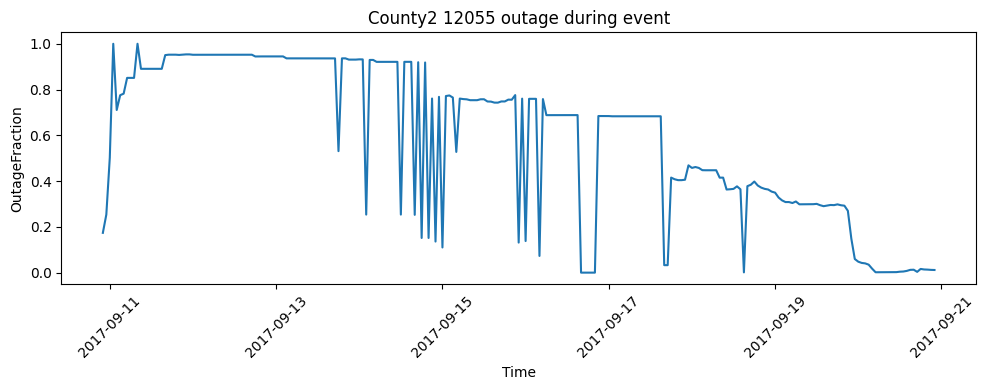

In [53]:
plt.figure(figsize=(10, 4))
plt.plot(one_event2_ts["RecordDateTime"], one_event2_ts["OutageFraction"])
plt.title(f"County2 {county2_fips} outage during event")
plt.xlabel("Time")
plt.ylabel("OutageFraction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

^ similarly weird noise in outage fraction
* So, let's inspect customersTracked again

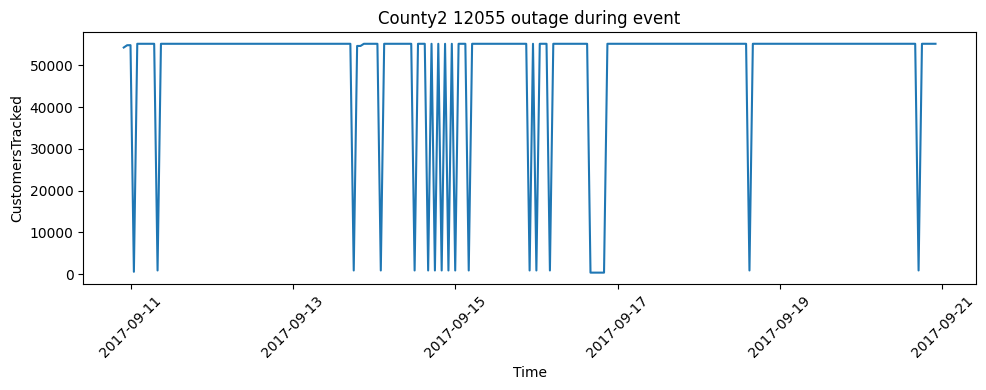

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(one_event2_ts["RecordDateTime"], one_event2_ts["CustomersTracked"])
plt.title(f"County2 {county2_fips} outage during event")
plt.xlabel("Time")
plt.ylabel("CustomersTracked")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

So, this seems like it will be a common (and heterogeneous) data corruption issue. 
- fix: create a 'valid data' mask

There are many ways of doing this, but a simple one is: if the CustomersTracked value goes below half of its max value during the event, then there is a corruption issue

In [55]:
threshold = 0.5 * one_event2_ts["CustomersTracked"].max()
one_event2_ts["valid"] = one_event2_ts["CustomersTracked"] > threshold

In [ ]:
one_event2_ts["OutageFraction_filtered"] = one_event2_ts["OutageFraction"].where(one_event2_ts["valid"])

^ Using *.where(valid)* keeps rows, inserts NaNs, thus showing gaps.

If using .loc[valid], it would remove rows entirely, so the plot would connect remaining points

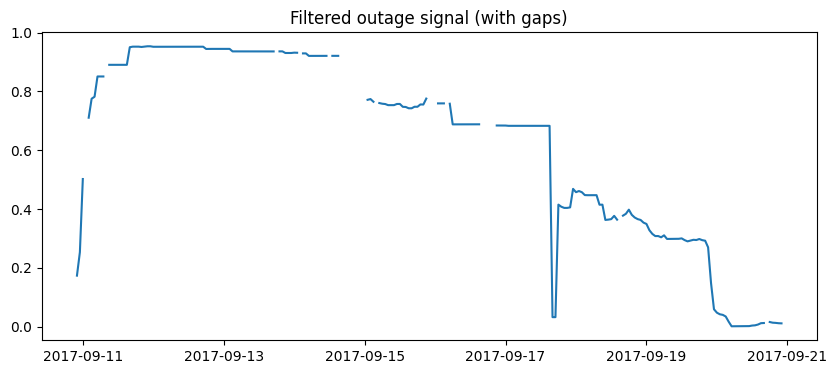

In [64]:
plt.figure(figsize=(10,4))
plt.plot(one_event2_ts["RecordDateTime"], one_event2_ts["OutageFraction_filtered"])
plt.title("Filtered outage signal (with gaps)")
plt.show()

^ the outage fraction does indeed go quite low on Sept 17th, while customersTracked stays high, which doesn't make much sense. Likely another data noise issue?

In [66]:
# take a look at these instances where the outageFraction is low but customersTracked is high (i.e. it looks like system recovery)
one_event2_ts.loc[
    (one_event2_ts["OutageFraction"] < 0.1) &
    (one_event2_ts["CustomersTracked"] > 0.8 * one_event2_ts["CustomersTracked"].max())
][["RecordDateTime", "OutageFraction", "CustomersTracked"]]

,RecordDateTime,OutageFraction,CustomersTracked
18914436,2017-09-17 16:00:00,0.032671,55156.0
18917471,2017-09-17 17:00:00,0.032671,55156.0
19081361,2017-09-19 23:00:00,0.059486,55156.0
19084396,2017-09-20 00:00:00,0.047828,55156.0
19087431,2017-09-20 01:00:00,0.042407,55156.0
19090466,2017-09-20 02:00:00,0.040431,55156.0
19093501,2017-09-20 03:00:00,0.034865,55156.0
19096536,2017-09-20 04:00:00,0.017296,55156.0
19099571,2017-09-20 05:00:00,0.001632,55156.0
19102606,2017-09-20 06:00:00,0.001759,55156.0


^ the first two datapoints are almost certainty faulty; nonsensical IRL recovery
- the later points are likely real recovery though
- So, I could make some minimum duration or smoothing. but for now, this is just an FYI

-- **Zooming out** --

Using Highlands County (pop: 105,618 people) during Hurricane Irma (2017) as an example still

In [67]:
# Step 1: extract full time series for that county
county_fips = event2["CountyFIPS"]

county_ts = ts_fl[ts_fl["CountyFIPS"] == county_fips].copy()

print(county_ts.shape)
county_ts = county_ts.sort_values("RecordDateTime")

(52561, 4)


In [68]:
# filter obviously bad data
county_ts["OutageFraction_filtered"] = county_ts["OutageFraction"].where(
    county_ts["CustomersTracked"] > 0
)

In [ ]:
# plot a long window (+/- 2 months around the event)
start = event2["event_start"] - pd.Timedelta(days=60)
end = event2["event_start"] + pd.Timedelta(days=60)

zoom_out_ts = county_ts[
    (county_ts["RecordDateTime"] >= start) &
    (county_ts["RecordDateTime"] <= end)
]

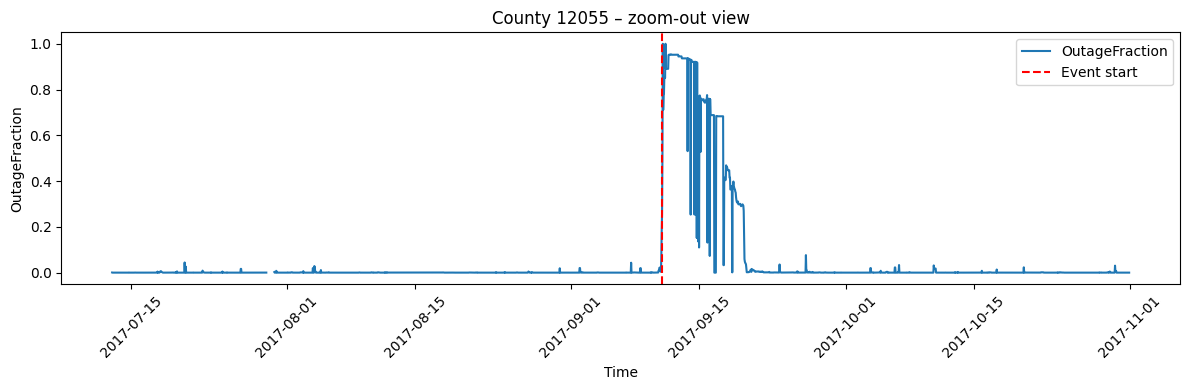

In [71]:
plt.figure(figsize=(12,4))

plt.plot(
    zoom_out_ts["RecordDateTime"],
    zoom_out_ts["OutageFraction_filtered"],
    label="OutageFraction"
)

# mark event start
plt.axvline(event2["event_start"], color="red", linestyle="--", label="Event start")

plt.title(f"County {county_fips} – zoom-out view")
plt.xlabel("Time")
plt.ylabel("OutageFraction")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

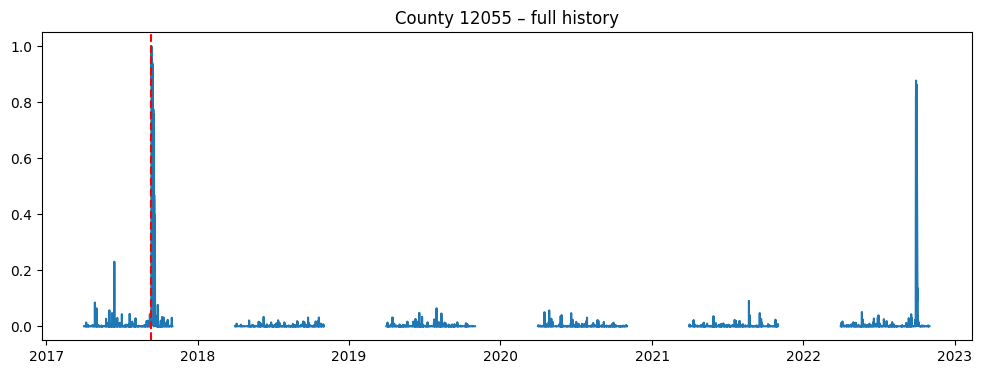

In [72]:
plt.figure(figsize=(12,4))
plt.plot(county_ts["RecordDateTime"], county_ts["OutageFraction_filtered"])
plt.axvline(event2["event_start"], color="red", linestyle="--")
plt.title(f"County {county_fips} – full history")
plt.show()